# Tree Search

Search algorithms which explore the search space without having any information about the problem other than its definition.

In this setting, we assume that the environment is:

- **Observable:** we know the current state
- **Discrete:** finite actions
- **Known:** which state is reached by each action
- **Deterministic:** each action has only one outcome

Under this assumption, and given an initial state, the solution to a problem is a fixed sequence of actions (the so-called "path").

# Problem Formulation

Problem formulation is the process of deciding which actions and states to consider, given a goal.

5 components can define a problem:

- The **initial state**
- The possible **actions**: by a function `ACTIONS(s)`
- A **transition model**: returns the state after the action `RESULT(s, a)`
- A **successor function**: returns all possible states from the current one `SUCCESSOR(s)`
The initial state, actions, and transition model implicitly define the **state space** of the problem, the set of all possible states reachable from the initial state. This state forms a **graph** in which nodes are states and links are actions.
- A **goal test**: is the current state a goal? `GOAL_TEST(s)`
The goal can be specified by:
    - an explicit list of goal states
    - an abstract property
- A **cost:** the cost of each step.
The sum of the step cost is the **path cost.**

The problem can be implemented in a single data structure, a class with:

Attributes:
    - initial state: initial state of the problem
    - goal state: configuration of the state that is a goal
    
Methods
    - goal test: if a state is a goal
    - actions: list of possible actions in a given state
    - result: state transition given state and an action
    - successors: all possible state reachable form a given state
    - cost: given a state and an action
    
Usually, the attributes remain the same, while the functions are specifically implemented for a given problem.

# Example: Streets Problem

Let's suppose we want to go from Corato to Bari, we need to understand how to formulate a problem. 
In this case, we can to model the environment (the links between these cities) as a dictionary.

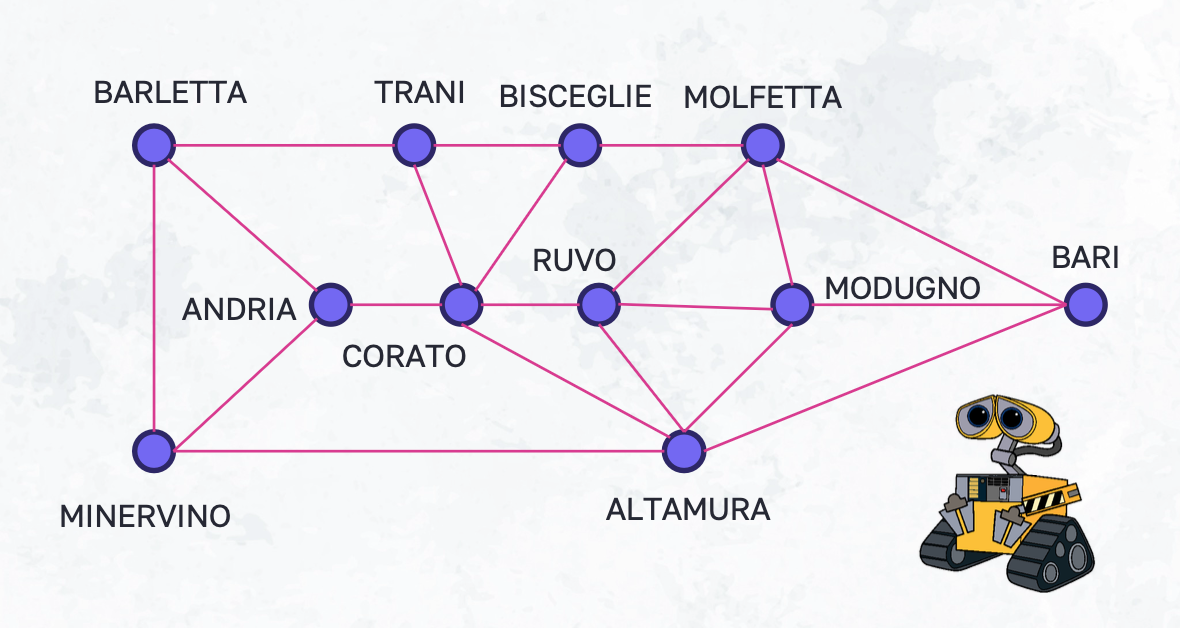

In [ ]:
from IPython.display import Image
Image(filename='images/map.png') 

In [ ]:
CORATO = 'Corato'
RUVO = 'Ruvo'
TRANI = 'Trani'
MOLFETTA = 'Molfetta'
ANDRIA = 'Andria'
BARLETTA = 'Barletta'
MINERVINO = 'Minervino'
ALTAMURA = 'Altamura'
BISCEGLIE = 'Bisceglie'
MODUGNO = 'Modugno'
BARI = 'Bari'

In [56]:
streets = [(CORATO, TRANI, 14), (CORATO, BISCEGLIE, 13), (CORATO, RUVO, 10), (CORATO, ALTAMURA, 40),
           (CORATO, ANDRIA, 15), (BARLETTA, TRANI, 13), (BARLETTA, ANDRIA, 10), (BARLETTA, MINERVINO, 35),
           (ANDRIA, MINERVINO, 24), (MINERVINO, ALTAMURA, 50), (TRANI, BISCEGLIE, 8), (BISCEGLIE, MOLFETTA, 10),
           (MOLFETTA, RUVO, 14), (MOLFETTA, MODUGNO, 22), (MOLFETTA, BARI, 25), (RUVO, MODUGNO, 26),
           (RUVO, ALTAMURA, 34), (ALTAMURA, MODUGNO, 36), (ALTAMURA, BARI, 45), (RUVO, ALTAMURA, 34),
           (MODUGNO, BARI, 22)]

apulian_map = {}

for cities in streets:
    c1, c2, cost = cities
    if apulian_map.get(c1, None) is not None:
        apulian_map[c1][c2] = cost
    else:
        apulian_map[c1] = {c2: cost}
    if apulian_map.get(c2, None) is not None:
        apulian_map[c2][c1] = cost
    else:
        apulian_map[c2] = {c1: cost}

print(apulian_map)

{'Corato': {'Trani': 14, 'Bisceglie': 13, 'Ruvo': 10, 'Altamura': 40, 'Andria': 15}, 'Trani': {'Corato': 14, 'Barletta': 13, 'Bisceglie': 8}, 'Bisceglie': {'Corato': 13, 'Trani': 8, 'Molfetta': 10}, 'Ruvo': {'Corato': 10, 'Molfetta': 14, 'Modugno': 26, 'Altamura': 34}, 'Altamura': {'Corato': 40, 'Minervino': 50, 'Ruvo': 34, 'Modugno': 36, 'Bari': 45}, 'Andria': {'Corato': 15, 'Barletta': 10, 'Minervino': 24}, 'Barletta': {'Trani': 13, 'Andria': 10, 'Minervino': 35}, 'Minervino': {'Barletta': 35, 'Andria': 24, 'Altamura': 50}, 'Molfetta': {'Bisceglie': 10, 'Ruvo': 14, 'Modugno': 22, 'Bari': 25}, 'Modugno': {'Molfetta': 22, 'Ruvo': 26, 'Altamura': 36, 'Bari': 22}, 'Bari': {'Molfetta': 25, 'Altamura': 45, 'Modugno': 22}}


Given the streets, that in some ways represent a constraints on the actions possible in each state, we can formulate the problem, based on the general formulation given above:

In [57]:
class StreetProblem:
    def __init__(self, initial_state, goal_state, steet_map):
        self.initial_state = initial_state
        self.goal_state = goal_state
        self.steet_map = steet_map

    def actions(self, state):
        return self.steet_map[state].keys()

    def result(self, state, action):
        if action in self.steet_map[state].keys():
            return action
        raise ValueError('Action not possible')

    def is_goal(self, state):
        return state == self.goal_state

    def action_cost(self, state, action):
        return self.steet_map[state][action]

Given this formulation of the street problem, we can now try its implementation

In [48]:
problem = StreetProblem(initial_state=CORATO, goal_state=BARI, steet_map=apulian_map)
print(problem.actions(MOLFETTA))
print(problem.result(MOLFETTA, MODUGNO))
print(problem.action_cost(MOLFETTA, MODUGNO))
print(problem.is_goal('Trani'))
print(problem.is_goal('Bari'))

Molfetta
{'Corato': {'Trani': 14, 'Bisceglie': 13, 'Ruvo': 10, 'Altamura': 40, 'Andria': 15}, 'Trani': {'Corato': 14, 'Barletta': 13, 'Bisceglie': 8}, 'Bisceglie': {'Corato': 13, 'Trani': 8, 'Molfetta': 10}, 'Ruvo': {'Corato': 10, 'Molfetta': 14, 'Modugno': 26, 'Altamura': 34}, 'Altamura': {'Corato': 40, 'Minervino': 50, 'Ruvo': 34, 'Modugno': 36, 'Bari': 45}, 'Andria': {'Corato': 15, 'Barletta': 10, 'Minervino': 24}, 'Barletta': {'Trani': 13, 'Andria': 10, 'Minervino': 35}, 'Minervino': {'Barletta': 35, 'Andria': 24, 'Altamura': 50}, 'Molfetta': {'Bisceglie': 10, 'Ruvo': 14, 'Modugno': 22, 'Bari': 25}, 'Modugno': {'Molfetta': 22, 'Ruvo': 26, 'Altamura': 36, 'Bari': 22}, 'Bari': {'Molfetta': 25, 'Altamura': 45, 'Modugno': 22}}
dict_keys(['Bisceglie', 'Ruvo', 'Modugno', 'Bari'])
22
22
False
True


# Search for a Solution

Having defined a problem, we now need to search for a solution, that is a series of action to reach the goal state. 
The possible sequence of action that an agent simulates form a search tree, that has the initial state as the root. 

The basic idea is that the agent can:
- check if a state is a goal state
- expands each state, generating its successor until it reaches a goal state. 

To do so, we need to maintain some additional data structures:
- the nodes in the tree
- the set of leaf node to expand (called **frontier** or **fringe**)
- a search strategy, to choose which node to expand next

# Infrastructure for search

# Fringe
The list of leaf node to expand can be implemented in a python list, that will be ordered by the given search strategy. 

The operation that we need to do on the fringe are:
- check if its is empty
- remove elements
- add elements

# Node

The nodes in the search tree can be also implemented as a class.

5 components can define a node:

Attributes:
- state
- parent
- action
- cost
- depth

More than one node can have the same state, since it is only used to keep track of the search. (the state is the representation of a physical configuration of the environment).

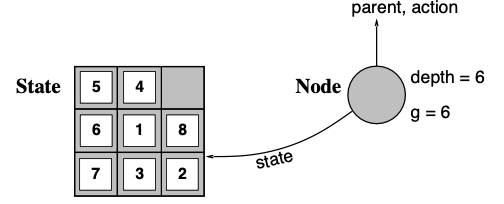

In [ ]:
from IPython.display import Image
Image(filename='images/node.png') 

A node has also some "helper" methods:
- path: traverses the tree to compute the path (the solution to the search problem)
- repr: a method that simplyfies node printing and inspection

In [44]:
class Node:
    def __init__(self, state, action, parent, path_cost):
        self.state = state
        self.action = action
        self.parent = parent
        self.path_cost = path_cost

    def __repr__(self):
        if self.parent is None:
            return f"([ROOT NODE] State: {self.state}, Action: {self.action}, Cost: {self.path_cost})"
        return f"([NODE] State: {self.state}, Action: {self.action}, Parent: {self.parent.state}, Cost: {self.path_cost})"

    def path(self):
        if self.parent is None:
            return []
        parent_path = self.parent.path()
        parent_path.append(self.action)
        return parent_path


Given the definition of a node, we can now try its implementation.

In [31]:
node = Node(state=TRANI, action=None, parent=None, path_cost=0)
print(node)

([ROOT NODE] State: Trani, Action: None, Cost: 0)


# Search Implementation

## Tree Search

As we know the tree search takes in input a search problem (and a strategy) and returns a solution.
Also, the general tree search can be implemented as a class, with:

Attributes:
    - problem
    - strategy
    - fringe
    
and only one method `RUN` that implements the algorithm, as shown in the pseudocode.


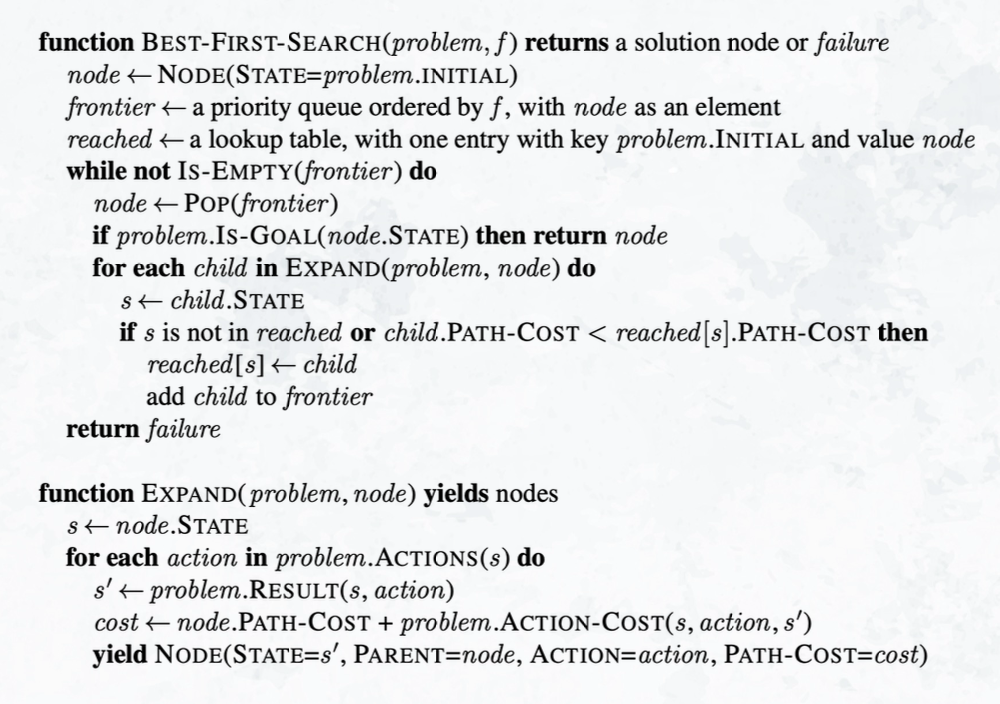

In [ ]:
from IPython.display import Image
Image(filename='images/search.png') 

In [45]:
def expand(node, problem):
    actions = problem.actions(node.state)
    new_nodes = []
    for action in actions:
        new_state = problem.result(node.state, action)
        new_node = Node(state=new_state, action=action, parent=node, path_cost=node.path_cost+problem.action_cost(node.state, action))    
        new_nodes.append(new_node)
    return new_nodes

class Search:

    def __init__(self, problem, strategy) -> None:
        self.problem: StreetProblem = problem
        self.strategy = strategy

    def run(self):
        root_node = Node(state=self.problem.initial_state, action=None, parent=None, path_cost=0)
        fringe = [root_node]
        visited = []

        while len(fringe) > 0:
            fringe, node = self.strategy.select(fringe)
            
            if self.problem.is_goal(node.state):
                return node

            new_nodes = expand(node, self.problem)
            fringe = fringe + new_nodes
        
        return None


Also, the search strategies can be implemented as their own class, with the method `SELECT(fringe)`.

For example, we can implement a random strategy in this way:

In [33]:
import random

class RandomStrategy:
    def select(self, fringe):
        random.shuffle(fringe)
        return fringe, fringe.pop(0)
    
# NB: list.pop(pos) -> pos is optional. A number specifying the position of the element you want to remove, default value is -1, which returns the last item.

and run the search:

In [59]:
problem = StreetProblem(initial_state=CORATO, goal_state=BARI, steet_map=apulian_map)
search = Search(problem, RandomStrategy())

for seed in range(10):
    random.seed(42+seed)
    result = search.run()
    if result is not None:
        path = result.path()
        print(path)

['Ruvo', 'Modugno', 'Bari']
['Bisceglie', 'Corato', 'Ruvo', 'Altamura', 'Bari']
['Bisceglie', 'Molfetta', 'Bari']
['Ruvo', 'Molfetta', 'Bari']
['Bisceglie', 'Trani', 'Corato', 'Ruvo', 'Modugno', 'Bari']
['Altamura', 'Bari']
['Altamura', 'Ruvo', 'Altamura', 'Modugno', 'Ruvo', 'Modugno', 'Bari']
['Bisceglie', 'Molfetta', 'Bari']
['Andria', 'Minervino', 'Altamura', 'Bari']
['Altamura', 'Modugno', 'Bari']


### HOMEWORK

- implement Tree Search with 'early goal check'
- implement all the uninformed strategies
- implement the redundant paths check (Graph Search)
- add the depth field to the node structure (necessary for strategies based on the Tree depth)